In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../datasets/alzheimers_disease_data.csv')
print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (2149, 35)

First 3 rows:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid


In [4]:
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train positive rate: {y_train.mean()*100:.1f}%")
print(f"Test positive rate:  {y_test.mean()*100:.1f}%")

Train size: 1719 | Test size: 430
Train positive rate: 35.4%
Test positive rate:  35.3%


In [5]:
configs = {
    "Config 1\n(Default LR)": LogisticRegression(
        solver='lbfgs', C=1.0, max_iter=1000, random_state=42
    ),
    "Config 2\n(Strong L2)": LogisticRegression(
        solver='lbfgs', C=0.01, penalty='l2', max_iter=1000, random_state=42
    ),
    "Config 3\n(Weak L2)": LogisticRegression(
        solver='lbfgs', C=100.0, penalty='l2', max_iter=1000, random_state=42
    ),
    "Config 4\n(L1 Penalty)": LogisticRegression(
        solver='liblinear', C=1.0, penalty='l1', max_iter=1000, random_state=42
    ),
    "Config 5\n(ElasticNet)": LogisticRegression(
        solver='saga', C=1.0, penalty='elasticnet', l1_ratio=0.5,
        max_iter=2000, random_state=42
    ),
    "Config 6\n(Class Balanced)": LogisticRegression(
        solver='lbfgs', C=1.0, class_weight='balanced',
        max_iter=1000, random_state=42
    ),
}

print(f"Total configurations: {len(configs)}")
for name, model in configs.items():
    print(f"  {name.replace(chr(10), ' ')}")

Total configurations: 6
  Config 1 (Default LR)
  Config 2 (Strong L2)
  Config 3 (Weak L2)
  Config 4 (L1 Penalty)
  Config 5 (ElasticNet)
  Config 6 (Class Balanced)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

results = []

for config_name, model in configs.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc       = accuracy_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)
    report    = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1']['precision']
    recall    = report['1']['recall']
    f1        = report['1']['f1-score']

    results.append({
        'Config': config_name.replace('\n', ' '),
        'Solver': model.solver,
        'C (Reg.)': model.C,
        'Penalty': model.penalty,
        'Class Weight': str(model.class_weight),
        'Accuracy': round(acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        '_model': model,
        '_y_pred': y_pred,
        '_y_prob': y_prob
    })

results_df = pd.DataFrame(results)
display_df = results_df.drop(columns=['_model', '_y_pred', '_y_prob'])
print("\n=== RESULTS TABLE ===")
print(display_df.to_string(index=False))


=== RESULTS TABLE ===
                   Config    Solver  C (Reg.)    Penalty Class Weight  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    Config 1 (Default LR)     lbfgs      1.00 deprecated         None    0.8163     0.7417  0.7368    0.7393   0.8854
     Config 2 (Strong L2)     lbfgs      0.01         l2         None    0.8256     0.8031  0.6711    0.7312   0.8842
       Config 3 (Weak L2)     lbfgs    100.00         l2         None    0.8163     0.7417  0.7368    0.7393   0.8854
    Config 4 (L1 Penalty) liblinear      1.00         l1         None    0.8186     0.7434  0.7434    0.7434   0.8858
    Config 5 (ElasticNet)      saga      1.00 elasticnet         None    0.8186     0.7467  0.7368    0.7417   0.8856
Config 6 (Class Balanced)     lbfgs      1.00 deprecated     balanced    0.8163     0.6952  0.8553    0.7670   0.8831


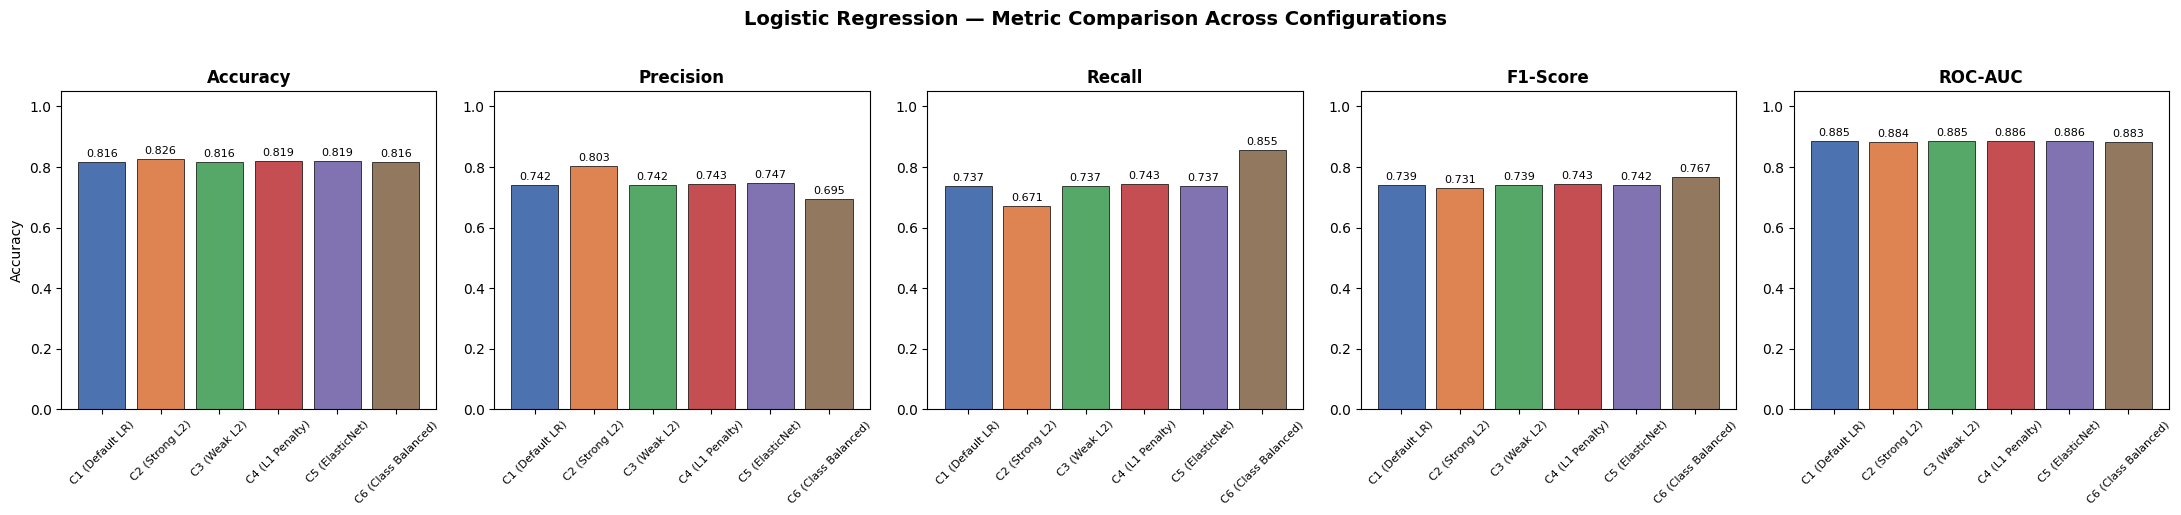

In [7]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
config_labels = [r['Config'].replace('Config ', 'C') for r in results]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Logistic Regression — Metric Comparison Across Configurations',
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for i, metric in enumerate(metrics):
    vals = [r[metric] for r in results]
    bars = axes[i].bar(config_labels, vals, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel(metric if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

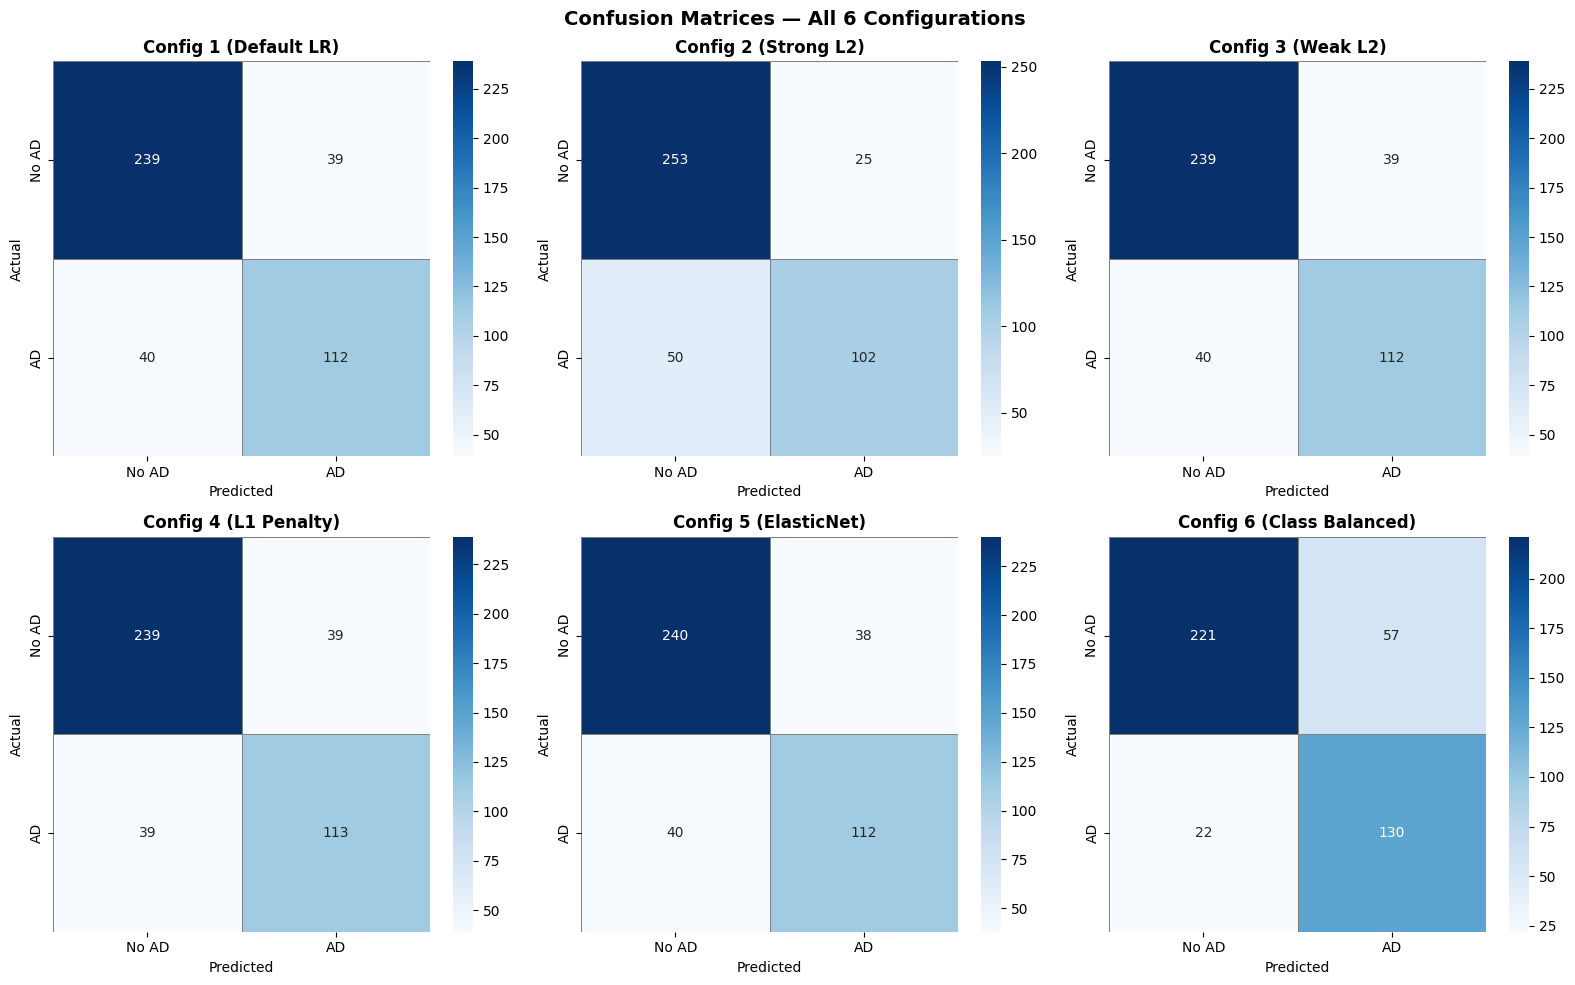

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, r in enumerate(results):
    cm = confusion_matrix(y_test, r['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No AD', 'AD'], yticklabels=['No AD', 'AD'],
                linewidths=0.5, linecolor='gray')
    axes[i].set_title(r['Config'], fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 6 Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

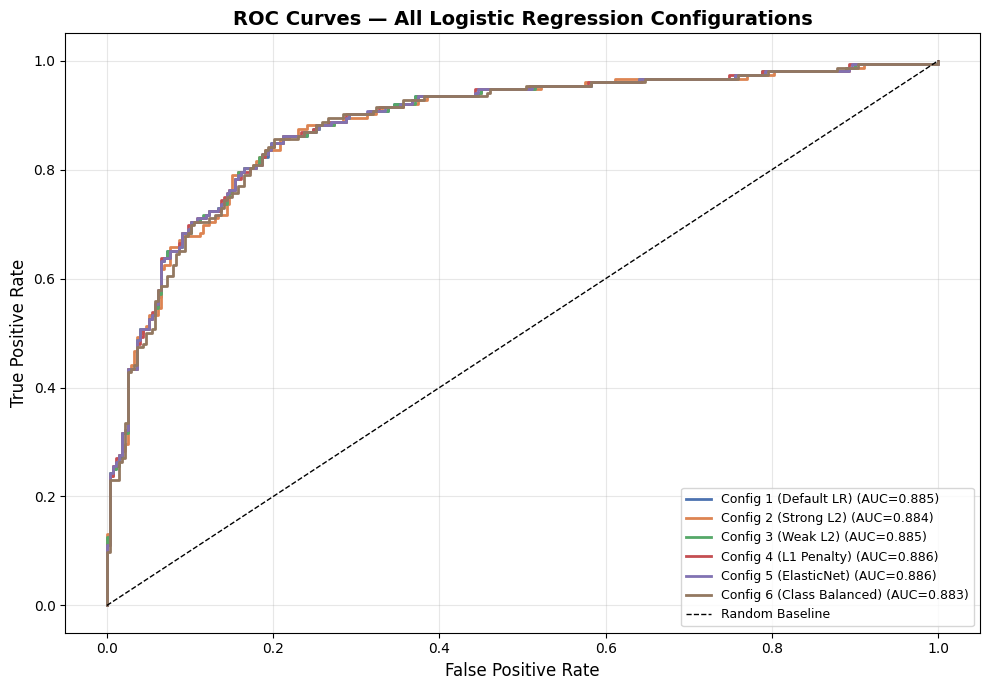

In [9]:
plt.figure(figsize=(10, 7))

colors_roc = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, r['_y_prob'])
    label = f"{r['Config']} (AUC={r['ROC-AUC']:.3f})"
    plt.plot(fpr, tpr, label=label, color=colors_roc[i], linewidth=2)

plt.plot([0,1],[0,1],'k--', label='Random Baseline', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Logistic Regression Configurations', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best Config: Config 4 (L1 Penalty)  |  ROC-AUC: 0.8858


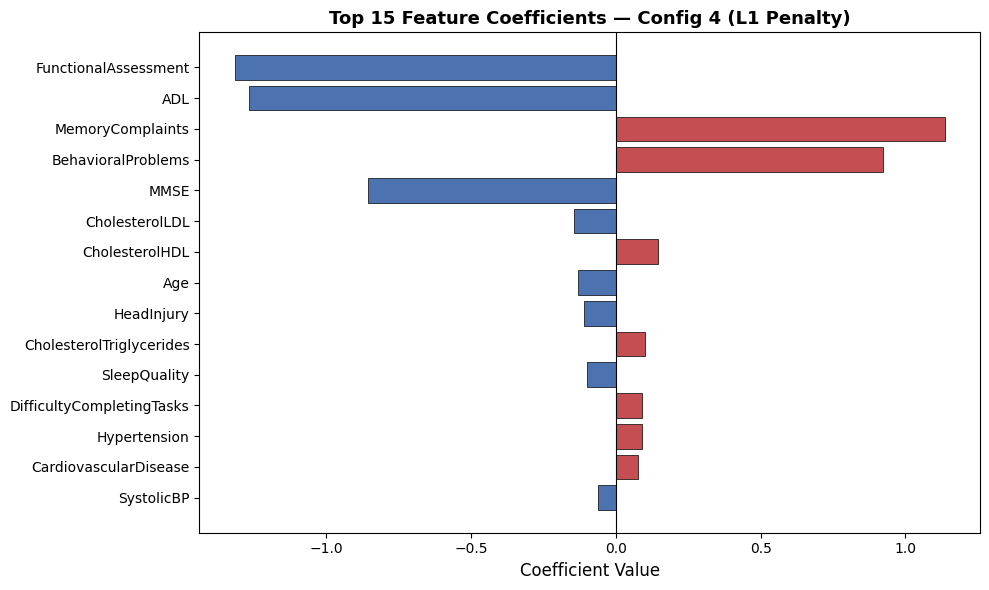

In [10]:
best = max(results, key=lambda r: r['ROC-AUC'])
print(f"Best Config: {best['Config']}  |  ROC-AUC: {best['ROC-AUC']}")

model_best = best['_model']
coef = model_best.coef_[0]
feat_names = X.columns.tolist()

coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coef})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors_feat = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_feat, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title(f'Top 15 Feature Coefficients — {best["Config"]}', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
print("=" * 75)
print("         FINAL SUMMARY — LOGISTIC REGRESSION CONFIGURATIONS")
print("=" * 75)

ranked = results_df.drop(columns=['_model','_y_pred','_y_prob']).sort_values(
    'ROC-AUC', ascending=False
).reset_index(drop=True)
ranked.index += 1
ranked.index.name = 'Rank'

# Highlight best values
print(ranked[['Config','Solver','C (Reg.)','Penalty','Accuracy',
              'Precision','Recall','F1-Score','ROC-AUC']].to_string())

print("\n Best by Accuracy :", ranked.loc[ranked['Accuracy'].idxmax(), 'Config'])
print(" Best by F1-Score  :", ranked.loc[ranked['F1-Score'].idxmax(), 'Config'])
print(" Best by ROC-AUC  :", ranked.loc[ranked['ROC-AUC'].idxmax(), 'Config'])

         FINAL SUMMARY — LOGISTIC REGRESSION CONFIGURATIONS
                         Config     Solver  C (Reg.)     Penalty  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Rank                                                                                                            
1         Config 4 (L1 Penalty)  liblinear      1.00          l1    0.8186     0.7434  0.7434    0.7434   0.8858
2         Config 5 (ElasticNet)       saga      1.00  elasticnet    0.8186     0.7467  0.7368    0.7417   0.8856
3            Config 3 (Weak L2)      lbfgs    100.00          l2    0.8163     0.7417  0.7368    0.7393   0.8854
4         Config 1 (Default LR)      lbfgs      1.00  deprecated    0.8163     0.7417  0.7368    0.7393   0.8854
5          Config 2 (Strong L2)      lbfgs      0.01          l2    0.8256     0.8031  0.6711    0.7312   0.8842
6     Config 6 (Class Balanced)      lbfgs      1.00  deprecated    0.8163     0.6952  0.8553    0.7670   0.8831

 Best by Accuracy : Config 2 (Stron

In [12]:
from joblib import dump
dump(model, 'logistic_regression.pkl')

['logistic_regression.pkl']